In [1]:
!pip install -q transformers  accelerate

In [2]:
import torch
from transformers import AutoModelForCausalLM,AutoTokenizer
target_name = "Qwen/Qwen2.5-1.5B-Instruct"
draft_name = "Qwen/Qwen2.5-0.5B-Instruct"

In [3]:
tokenizer=AutoTokenizer.from_pretrained(target_name)
target_model=AutoModelForCausalLM.from_pretrained(target_name,torch_dtype=torch.float16,device_map="cuda")
draft_model = AutoModelForCausalLM.from_pretrained(
    draft_name,
    torch_dtype=torch.float16,
    device_map="cuda"
)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [4]:
target_model.eval()
draft_model.eval()
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")

4.075527168 GB allocated


In [5]:
from transformers import GenerationConfig
greedy_config = GenerationConfig(
    do_sample=False,
    num_beams=1,
    temperature=None,
    top_p=None,
    top_k=None,
    repetition_penalty=1.0
)

In [6]:
prompt = "The capital of France is"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
with torch.no_grad():
  output=target_model.generate(**inputs,max_new_tokens=20,generation_config=greedy_config)
generated_ids=output[0][inputs["input_ids"].shape[1]:]
print(tokenizer.decode(generated_ids,skip_special_tokens=True))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


 Paris. The capital of France is also the capital of which country?
A) Germany
B)


In [7]:
def manual_generate(model, tokenizer, prompt, max_tokens=20):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        out = model(input_ids, use_cache=True)

    past_key_values = out.past_key_values

    next_token_logits = out.logits[:, -1, :]
    next_token = torch.argmax(
        next_token_logits,
        dim=1,
        keepdim=True
    )

    generated = []
    generated.append(next_token.item())

    for _ in range(max_tokens - 1):
        with torch.no_grad():
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )

        past_key_values = out.past_key_values

        next_token_logits = out.logits[:, -1, :]
        next_token = torch.argmax(
            next_token_logits,
            dim=-1,
            keepdim=True
        )

        generated.append(next_token.item())

        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated, skip_special_tokens=True)

In [8]:
#Verifying that manual generation's output matches the HF output
manual_output = manual_generate(
    target_model,
    tokenizer,
    prompt,
    max_tokens=20
)

print(manual_output)

 Paris. The capital of France is also the capital of which country?
A) Germany
B)


In [9]:
#Phase 2
#Same generation code , just used yield to stream the tokens
def generate_tokens(model, tokenizer, prompt, max_tokens=20):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model(inputs["input_ids"], use_cache=True)
    past_key_values = out.past_key_values
    next_token_logits = out.logits[:, -1, :]
    next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
    yield next_token.item()

    for _ in range(max_tokens - 1):
        with torch.no_grad():
            out = model(
                input_ids=next_token,
                past_key_values=past_key_values,
                use_cache=True
            )
        past_key_values = out.past_key_values
        next_token_logits = out.logits[:, -1, :]
        next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
        if next_token.item() == tokenizer.eos_token_id:
            break
        yield next_token.item()

In [10]:
!pip install -q fastapi uvicorn httpx

In [11]:
import threading
import uvicorn
import asyncio
import httpx
import time
import uuid
from fastapi import FastAPI
from fastapi.responses import StreamingResponse
from pydantic import BaseModel

In [12]:
class GenerateRequest(BaseModel):
  prompt:str
  max_tokens:int=20

app = FastAPI()

@app.post("/generate")
def generate_endpoint(request:GenerateRequest):
  def token_stream():
        for token_id in generate_tokens(target_model, tokenizer, request.prompt, request.max_tokens):
            text = tokenizer.decode([token_id])
            yield f"data: {text}\n\n"
  return StreamingResponse(token_stream(), media_type="text/event-stream")

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="warning")

thread = threading.Thread(target=run_server, daemon=True)
thread.start()

In [13]:
async def single_request(client, prompt, max_tokens=20, port=8000):
    start = time.perf_counter()
    first_token_time = None
    tokens = []

    async with client.stream(
        "POST", f"http://localhost:{port}/generate",
        json={"prompt": prompt, "max_tokens": max_tokens},
        timeout=60
    ) as response:
        async for line in response.aiter_lines():
            if line.startswith("data:"):
                now = time.perf_counter()
                if first_token_time is None:
                    first_token_time = now
                tokens.append(line[6:])

    end = time.perf_counter()
    decode_time = end - first_token_time
    decode_tokens = len(tokens) - 1
    tps = decode_tokens / decode_time if decode_time > 0 and decode_tokens > 0 else 0.0

    return {
        "ttft": (first_token_time - start) * 1000,
        "latency": (end - start) * 1000,
        "tokens": len(tokens),
        "tps": tps
    }

async def run_load_test(concurrency, prompt="The capital of France is", prompts=None, max_tokens=20, port=8000):
    if prompts is None:
        prompts = [prompt]
    async with httpx.AsyncClient() as client:
        batch_start = time.perf_counter()
        tasks = [single_request(client, prompts[i % len(prompts)], max_tokens, port) for i in range(concurrency)]
        results = await asyncio.gather(*tasks)
        batch_end = time.perf_counter()
    return results, batch_end - batch_start

results_log = []

def summarize(results, concurrency, wall_time, phase="dumb_baseline"):
    ttfts = sorted(r["ttft"] for r in results)
    latencies = sorted(r["latency"] for r in results)
    tps_values = sorted(r["tps"] for r in results)
    total_tokens = sum(r["tokens"] for r in results)
    aggregate_tps = total_tokens / wall_time

    def pct(values, p):
        idx = min(int(len(values) * p), len(values) - 1)
        return values[idx]

    row = {
        "phase": phase,
        "concurrency": concurrency,
        "ttft_p50": pct(ttfts, 0.5), "ttft_p95": pct(ttfts, 0.95), "ttft_p99": pct(ttfts, 0.99),
        "latency_p50": pct(latencies, 0.5), "latency_p95": pct(latencies, 0.95),
        "tps_p50": pct(tps_values, 0.5),
        "aggregate_tps": aggregate_tps
    }
    results_log.append(row)

    print(f"concurrency={concurrency}")
    print(f"  TTFT        p50={row['ttft_p50']:.1f}ms  p95={row['ttft_p95']:.1f}ms  p99={row['ttft_p99']:.1f}ms")
    print(f"  latency     p50={row['latency_p50']:.1f}ms  p95={row['latency_p95']:.1f}ms")
    print(f"  per-req TPS p50={row['tps_p50']:.1f}")
    print(f"  aggregate throughput = {row['aggregate_tps']:.1f} tokens/sec")

In [15]:
await run_load_test(1, max_tokens=5, port=8000)
for concurrency in [1, 5, 10, 20]:
    results, wall_time = await run_load_test(concurrency, max_tokens=20, port=8000)
    summarize(results, concurrency, wall_time, phase="dumb_baseline")

concurrency=1
  TTFT        p50=48.4ms  p95=48.4ms  p99=48.4ms
  latency     p50=838.6ms  p95=838.6ms
  per-req TPS p50=24.0
  aggregate throughput = 23.8 tokens/sec
concurrency=5
  TTFT        p50=450.3ms  p95=455.1ms  p99=455.1ms
  latency     p50=8260.9ms  p95=8273.8ms
  per-req TPS p50=2.4
  aggregate throughput = 12.1 tokens/sec
concurrency=10
  TTFT        p50=1120.4ms  p95=1137.7ms  p99=1137.7ms
  latency     p50=20419.5ms  p95=20453.3ms
  per-req TPS p50=1.0
  aggregate throughput = 9.8 tokens/sec
concurrency=20
  TTFT        p50=2064.2ms  p95=2124.3ms  p99=2124.3ms
  latency     p50=38831.9ms  p95=38884.9ms
  per-req TPS p50=0.5
  aggregate throughput = 10.3 tokens/sec


In [16]:
class Request:
  def __init__(self,prompt,max_tokens):
    self.id=str(uuid.uuid4())
    self.prompt=prompt
    self.max_tokens=max_tokens
    self.generator=None
    self.queue=asyncio.Queue()

class RequestManager:
    def __init__(self, generator_fn, max_batch_size=8):
        self.waiting = []
        self.running = {}
        self.max_batch_size = max_batch_size
        self.generator_fn = generator_fn

    def submit(self, request):
        self.waiting.append(request)

    def admit_waiting(self):
        while self.waiting and len(self.running) < self.max_batch_size:
            req = self.waiting.pop(0)
            req.generator = self.generator_fn(req, self.waiting)
            self.running[req.id] = req

    async def step(self):
        finished_ids = []
        for req_id, req in list(self.running.items()):
            try:
                token_id = next(req.generator)
                text = tokenizer.decode([token_id])
                await req.queue.put(text)
                await asyncio.sleep(0)
            except StopIteration:
                finished_ids.append(req_id)
        for req_id in finished_ids:
            req = self.running.pop(req_id)
            await req.queue.put(None)

async def scheduler_loop(manager):
    while True:
        manager.admit_waiting()
        if manager.running:
            await manager.step()
        else:
            await asyncio.sleep(0.01)

In [17]:
def plain_generator_fn(req, waiting):
    return generate_tokens(target_model, tokenizer, req.prompt, req.max_tokens)

manager_v1 = RequestManager(plain_generator_fn, max_batch_size=8)

app_v1 = FastAPI()

@app_v1.on_event("startup")
async def startup_event_v1():
    asyncio.create_task(scheduler_loop(manager_v1))

@app_v1.post("/generate")
async def generate_endpoint_v1(request: GenerateRequest):
    req = Request(request.prompt, request.max_tokens)
    manager_v1.submit(req)

    async def event_stream():
        while True:
            text = await req.queue.get()
            if text is None:
                break
            yield f"data: {text}\n\n"

    return StreamingResponse(event_stream(), media_type="text/event-stream")

def run_server_v1():
    uvicorn.run(app_v1, host="0.0.0.0", port=8001, log_level="warning")

thread_v1 = threading.Thread(target=run_server_v1, daemon=True)
thread_v1.start()

/tmp/ipykernel_58/1691372160.py:8: DeprecationWarning: 
        on_event is deprecated, use lifespan event handlers instead.

        Read more about it in the
        [FastAPI docs for Lifespan Events](https://fastapi.tiangolo.com/advanced/events/).
        
  @app_v1.on_event("startup")


In [18]:
async def check_interleave():
    async with httpx.AsyncClient() as client:
        async def one(label, prompt):
            start = time.perf_counter()
            async with client.stream("POST", "http://localhost:8001/generate", json={"prompt": prompt, "max_tokens": 15}, timeout=30) as r:
                async for line in r.aiter_lines():
                    if line.startswith("data:"):
                        print(label, round((time.perf_counter()-start)*1000,1), "ms:", line[6:])
        await asyncio.gather(one("R1", "The capital of France is"), one("R2", "The capital of Japan is"))

await check_interleave()

R1 94.9 ms:  Paris
R1 136.5 ms: .
R1 180.9 ms:  The
R2 221.1 ms:  Tokyo
R1 263.2 ms:  capital
R2 306.2 ms: .
R1 350.7 ms:  of
R2 390.4 ms:  Tokyo
R1 429.7 ms:  France
R2 469.0 ms:  is
R1 508.5 ms:  is
R2 551.3 ms:  the
R1 592.4 ms:  also
R2 632.0 ms:  largest
R1 673.2 ms:  the
R2 713.5 ms:  city
R1 754.6 ms:  capital
R2 794.3 ms:  in
R1 834.7 ms:  of
R2 876.7 ms:  Japan
R1 916.9 ms:  which
R2 957.5 ms: .
R1 998.0 ms:  country
R2 1036.8 ms:  It
R1 1077.2 ms: ?
R2 1115.9 ms:  is
R1 1156.8 ms: A
R2 1196.3 ms:  also
R2 1236.1 ms:  the
R2 1237.0 ms:  capital


In [19]:
for concurrency in [1, 5, 10, 20]:
    results, wall_time = await run_load_test(concurrency, max_tokens=20, port=8001)
    summarize(results, concurrency, wall_time, phase="continuous_batching_v1")

concurrency=1
  TTFT        p50=99.7ms  p95=99.7ms  p99=99.7ms
  latency     p50=810.6ms  p95=810.6ms
  per-req TPS p50=26.7
  aggregate throughput = 24.7 tokens/sec
concurrency=5
  TTFT        p50=193.4ms  p95=277.4ms  p99=277.4ms
  latency     p50=4029.9ms  p95=4030.4ms
  per-req TPS p50=5.0
  aggregate throughput = 24.8 tokens/sec
concurrency=10
  TTFT        p50=415.1ms  p95=6468.4ms  p99=6468.4ms
  latency     p50=6509.8ms  p95=7926.9ms
  per-req TPS p50=3.1
  aggregate throughput = 25.2 tokens/sec
concurrency=20
  TTFT        p50=6724.1ms  p95=13214.7ms  p99=13214.7ms
  latency     p50=13080.5ms  p95=16158.9ms
  per-req TPS p50=3.0
  aggregate throughput = 24.8 tokens/sec


In [20]:
import copy
#Min tokens  that have to be same to get an entry into the prefix cache
MIN_SHARED_PREFIX_LEN=3
prefix_cache_pool={}
#Check how many tokens are matching between 2 sequences
def shared_prefix_len(tokens_a,tokens_b):
  length=0
  for a,b in zip(tokens_a,tokens_b):
    if a!=b:
      break
    length+=1
  return length
  #If a request comes say The capital is , and say cache has "The capital","The capital is" ,we will choose the bigger prefix ofc
def find_cached_prefix(token_ids):
    best = None
    for cached_ids in prefix_cache_pool:
        n = len(cached_ids)
        if len(token_ids) >= n and tuple(token_ids[:n]) == cached_ids:
            if best is None or n > len(best):
                best = cached_ids
    return best
  #Mechanism to cache a prefix (just generate it)
def cache_prefix(model, tokenizer, token_ids):
    input_ids = torch.tensor([token_ids]).to("cuda")
    with torch.no_grad():
        out = model(input_ids, use_cache=True)
    next_token = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)
    prefix_cache_pool[tuple(token_ids)] = {
        "kv": out.past_key_values,
        "first_token": next_token
    }
#Now say  there is a prefix match ok , and now we have a prompt saying the capital of France is and say  the capital is the prefix part , so rest is suffix
def generate_tokens_with_prefix_ids(model, tokenizer, cached_entry, suffix_ids, max_tokens=20):
    past_key_values = copy.deepcopy(cached_entry["kv"])
    #We are using past kv cache for the matchign prefix
    if suffix_ids:
        input_ids = torch.tensor([suffix_ids]).to("cuda")
        with torch.no_grad():
            out = model(input_ids=input_ids, past_key_values=past_key_values, use_cache=True)
        past_key_values = out.past_key_values
        next_token = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)
        #If prefix=prompt , then we already have the cached first token
    else:
        next_token = cached_entry["first_token"]

    yield next_token.item()
  # Then basic autoregressive decoding  since prefix caching only helps in prefill part
    for _ in range(max_tokens - 1):
        with torch.no_grad():
            out = model(input_ids=next_token, past_key_values=past_key_values, use_cache=True)
        past_key_values = out.past_key_values
        next_token = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)
        if next_token.item() == tokenizer.eos_token_id:
            break
        yield next_token.item()

In [21]:
def resolve_prompt(model,tokenizer,prompt,waiting_prompts,max_tokens=20):
  token_ids=tokenizer(prompt)["input_ids"]
  matched_prefix=find_cached_prefix(token_ids)

  if matched_prefix is None:
    for other_prompt  in waiting_prompts:
      other_ids=tokenizer(other_prompt)["input_ids"]
      shared_len=shared_prefix_len(token_ids,other_ids)
      if shared_len>=MIN_SHARED_PREFIX_LEN:
        cache_prefix(model,tokenizer,token_ids[:shared_len])
        matched_prefix=tuple(token_ids[:shared_len])
        break
  if matched_prefix:
    suffix_ids=token_ids[len(matched_prefix):]
    cached_entry=prefix_cache_pool[matched_prefix]
    return generate_tokens_with_prefix_ids(model,tokenizer,cached_entry,suffix_ids,max_tokens)
  else:
      return generate_tokens(model,tokenizer,prompt,max_tokens)

In [22]:
prefix_check_prompts = [
    "The capital of France is",
    "The capital of Japan is",
    "The capital of Germany is",
]

prefix_cache_pool.clear()

for i, prompt in enumerate(prefix_check_prompts):
    others = prefix_check_prompts[:i] + prefix_check_prompts[i+1:]
    baseline = list(generate_tokens(target_model, tokenizer, prompt, max_tokens=15))
    cached = list(resolve_prompt(target_model, tokenizer, prompt, others, max_tokens=15))
    print(prompt)
    print("  baseline:", tokenizer.decode(baseline, skip_special_tokens=True))
    print("  cached:  ", tokenizer.decode(cached, skip_special_tokens=True))
    print("  match:", baseline == cached)

The capital of France is
  baseline:  Paris. The capital of France is also the capital of which country?
A
  cached:    Paris. The capital of France is also the capital of which country?
A
  match: True
The capital of Japan is
  baseline:  Tokyo. Tokyo is the largest city in Japan. It is also the capital
  cached:    Tokyo. Tokyo is the largest city in Japan. It is also the capital
  match: True
The capital of Germany is
  baseline:  Berlin. The capital of Germany is Berlin. The capital of Germany is Berlin
  cached:    Berlin. The capital of Germany is Berlin. The capital of Germany is Berlin
  match: True


In [23]:
def cache_length(past_key_values):
    return past_key_values.get_seq_length()

def truncate_kv_cache(past_key_values, keep_length):
    past_key_values.crop(keep_length)
    return past_key_values

def speculative_round(target_model, draft_model, tokenizer, target_kv, draft_kv, last_token, k=4):
    pre_round_length = cache_length(target_kv)

    draft_tokens = []
    current_input = last_token
    current_draft_kv = draft_kv

    for _ in range(k):
        with torch.no_grad():
            out = draft_model(input_ids=current_input, past_key_values=current_draft_kv, use_cache=True)
        current_draft_kv = out.past_key_values
        current_input = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)
        draft_tokens.append(current_input)

    draft_tensor = torch.cat([last_token] + draft_tokens, dim=1)
    with torch.no_grad():
        target_out = target_model(input_ids=draft_tensor, past_key_values=target_kv, use_cache=True)
    target_kv = target_out.past_key_values
    target_logits = target_out.logits

    accept_len = 0
    corrected_token = None
    for i in range(k):
        target_pred = torch.argmax(target_logits[:, i, :], dim=-1, keepdim=True)
        if target_pred.item() == draft_tokens[i].item():
            accept_len += 1
        else:
            corrected_token = target_pred
            break

    if corrected_token is not None:
        new_last_token = corrected_token
        keep_length = pre_round_length + 1 + accept_len
        target_kv = truncate_kv_cache(target_kv, keep_length)
        draft_kv = truncate_kv_cache(current_draft_kv, keep_length)
    else:
        new_last_token = torch.argmax(target_logits[:, k, :], dim=-1, keepdim=True)
        with torch.no_grad():
            extra = draft_model(input_ids=draft_tokens[k - 1], past_key_values=current_draft_kv, use_cache=True)
        draft_kv = extra.past_key_values

    accepted_tokens = [t.item() for t in draft_tokens[:accept_len]] + [new_last_token.item()]
    return accepted_tokens, new_last_token, target_kv, draft_kv

def speculative_generate(target_model, draft_model, tokenizer, prompt, k=4, max_tokens=20):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        target_out = target_model(input_ids, use_cache=True)
        draft_out = draft_model(input_ids, use_cache=True)

    target_kv = target_out.past_key_values
    draft_kv = draft_out.past_key_values
    last_token = torch.argmax(target_out.logits[:, -1, :], dim=-1, keepdim=True)

    tokens_yielded = 1
    yield last_token.item()
    if last_token.item() == tokenizer.eos_token_id:
        return

    while tokens_yielded < max_tokens:
        round_k = min(k, max_tokens - tokens_yielded)
        accepted_tokens, last_token, target_kv, draft_kv = speculative_round(
            target_model, draft_model, tokenizer, target_kv, draft_kv, last_token, k=round_k
        )
        for t in accepted_tokens:
            if tokens_yielded >= max_tokens:
                return
            yield t
            tokens_yielded += 1
            if t == tokenizer.eos_token_id:
                return

In [24]:
def spec_vs_baseline_check(prompt, max_tokens=20, k=4):
    baseline = list(generate_tokens(target_model, tokenizer, prompt, max_tokens))
    spec = list(speculative_generate(target_model, draft_model, tokenizer, prompt, k=k, max_tokens=max_tokens))
    print("baseline:", tokenizer.decode(baseline, skip_special_tokens=True))
    print("spec:    ", tokenizer.decode(spec, skip_special_tokens=True))
    print("match:", baseline == spec)

In [25]:
for prompt in [
    "The capital of France is",
    "The capital of Germany is",
]:
    print(prompt)
    spec_vs_baseline_check(prompt, max_tokens=20, k=4)
    print()

The capital of France is
baseline:  Paris. The capital of France is also the capital of which country?
A) Germany
B)
spec:      Paris. The capital of France is also the capital of which country?
A) Germany
B)
match: True

The capital of Germany is
baseline:  Berlin. The capital of Germany is Berlin. The capital of Germany is Berlin. The capital of Germany
spec:      Berlin. The capital of Germany is Berlin. The capital of Germany is Berlin. The capital of Germany
match: True



In [26]:
def cache_prefix_both(target_model, draft_model, tokenizer, token_ids):
    input_ids = torch.tensor([token_ids]).to("cuda")
    with torch.no_grad():
        target_out = target_model(input_ids, use_cache=True)
        draft_out = draft_model(input_ids, use_cache=True)
    first_token = torch.argmax(target_out.logits[:, -1, :], dim=-1, keepdim=True)
    prefix_cache_pool[tuple(token_ids)] = {
        "target_kv": target_out.past_key_values,
        "draft_kv": draft_out.past_key_values,
        "first_token": first_token
    }

def prefill_suffix_both(target_model, draft_model, tokenizer, cached_entry, suffix_ids):
    target_kv = copy.deepcopy(cached_entry["target_kv"])
    draft_kv = copy.deepcopy(cached_entry["draft_kv"])

    if suffix_ids:
        suffix_tensor = torch.tensor([suffix_ids]).to("cuda")
        with torch.no_grad():
            target_out = target_model(input_ids=suffix_tensor, past_key_values=target_kv, use_cache=True)
            draft_out = draft_model(input_ids=suffix_tensor, past_key_values=draft_kv, use_cache=True)
        target_kv = target_out.past_key_values
        draft_kv = draft_out.past_key_values
        last_token = torch.argmax(target_out.logits[:, -1, :], dim=-1, keepdim=True)
    else:
        last_token = cached_entry["first_token"]

    return target_kv, draft_kv, last_token

In [27]:
spec_stats = {"rounds": 0, "accepted": 0, "drafted": 0}

def combined_generate(target_model, draft_model, tokenizer, prompt, waiting_prompts,
                       use_prefix_cache=True, use_speculative=True, k=4, max_tokens=20):
    token_ids = tokenizer(prompt)["input_ids"]
    matched_prefix = None

    if use_prefix_cache:
        matched_prefix = find_cached_prefix(token_ids)
        if matched_prefix is None:
            for other_prompt in waiting_prompts:
                other_ids = tokenizer(other_prompt)["input_ids"]
                shared_len = shared_prefix_len(token_ids, other_ids)
                if shared_len >= MIN_SHARED_PREFIX_LEN:
                    cache_prefix_both(target_model, draft_model, tokenizer, token_ids[:shared_len])
                    matched_prefix = tuple(token_ids[:shared_len])
                    break

    if matched_prefix:
        suffix_ids = token_ids[len(matched_prefix):]
        cached_entry = prefix_cache_pool[matched_prefix]
        target_kv, draft_kv, last_token = prefill_suffix_both(target_model, draft_model, tokenizer, cached_entry, suffix_ids)
    else:
        input_ids = torch.tensor([token_ids]).to("cuda")
        with torch.no_grad():
            target_out = target_model(input_ids, use_cache=True)
        target_kv = target_out.past_key_values
        last_token = torch.argmax(target_out.logits[:, -1, :], dim=-1, keepdim=True)
        draft_kv = None
        if use_speculative:
            with torch.no_grad():
                draft_out = draft_model(input_ids, use_cache=True)
            draft_kv = draft_out.past_key_values

    tokens_yielded = 1
    yield last_token.item()
    if last_token.item() == tokenizer.eos_token_id:
        return

    while tokens_yielded < max_tokens:
        if use_speculative:
            round_k = min(k, max_tokens - tokens_yielded)
            accepted_tokens, last_token, target_kv, draft_kv = speculative_round(
                target_model, draft_model, tokenizer, target_kv, draft_kv, last_token, k=round_k
            )
            spec_stats["rounds"] += 1
            spec_stats["accepted"] += len(accepted_tokens)
            spec_stats["drafted"] += round_k
        else:
            with torch.no_grad():
                out = target_model(input_ids=last_token, past_key_values=target_kv, use_cache=True)
            target_kv = out.past_key_values
            last_token = torch.argmax(out.logits[:, -1, :], dim=-1, keepdim=True)
            accepted_tokens = [last_token.item()]

        for t in accepted_tokens:
            if tokens_yielded >= max_tokens:
                return
            yield t
            tokens_yielded += 1
            if t == tokenizer.eos_token_id:
                return

In [28]:
def check_combined(prompt, waiting_prompts, max_tokens=20, k=4):
    baseline = list(generate_tokens(target_model, tokenizer, prompt, max_tokens))
    combined = list(combined_generate(target_model, draft_model, tokenizer, prompt, waiting_prompts,
                                       use_prefix_cache=True, use_speculative=True, k=k, max_tokens=max_tokens))
    print("baseline:", tokenizer.decode(baseline, skip_special_tokens=True))
    print("combined:", tokenizer.decode(combined, skip_special_tokens=True))
    print("match:", baseline == combined)

prefix_cache_pool.clear()
others = ["You are a helpful assistant. What is the capital of Japan?"]
check_combined("You are a helpful assistant. What is the capital of France?", others, max_tokens=20, k=4)

baseline:  The capital of France is Paris. Paris is a city located in the northwestern part of France and
combined:  The capital of France is Paris. Paris is a city located in the northwestern part of France and
match: True


In [29]:
CURRENT_K = 4

def combined_generator_fn(req, waiting):
    waiting_prompts = [r.prompt for r in waiting]
    return combined_generate(target_model, draft_model, tokenizer, req.prompt, waiting_prompts,
                              use_prefix_cache=True, use_speculative=True, k=CURRENT_K, max_tokens=req.max_tokens)

manager_combined = RequestManager(combined_generator_fn, max_batch_size=8)

app_combined = FastAPI()

@app_combined.on_event("startup")
async def startup_event_combined():
    asyncio.create_task(scheduler_loop(manager_combined))

@app_combined.post("/generate")
async def generate_endpoint_combined(request: GenerateRequest):
    req = Request(request.prompt, request.max_tokens)
    manager_combined.submit(req)

    async def event_stream():
        while True:
            text = await req.queue.get()
            if text is None:
                break
            yield f"data: {text}\n\n"

    return StreamingResponse(event_stream(), media_type="text/event-stream")

def run_server_combined():
    uvicorn.run(app_combined, host="0.0.0.0", port=8002, log_level="warning")

thread_combined = threading.Thread(target=run_server_combined, daemon=True)
thread_combined.start()

/tmp/ipykernel_58/1253450267.py:12: DeprecationWarning: 
        on_event is deprecated, use lifespan event handlers instead.

        Read more about it in the
        [FastAPI docs for Lifespan Events](https://fastapi.tiangolo.com/advanced/events/).
        
  @app_combined.on_event("startup")


In [30]:
SHARED_PREFIX = "You are a helpful assistant. Answer concisely: "

test_questions = [
    "What is the capital of France?",
    "What is the capital of Japan?",
    "What is the capital of Germany?",
    "What is the capital of Italy?",
    "What is the capital of Spain?",
    "What is the capital of Canada?",
    "What is the capital of Brazil?",
    "What is the capital of Egypt?",
]
combined_test_prompts = [SHARED_PREFIX + q for q in test_questions]

prefix_cache_pool.clear()

for concurrency in [1, 5, 10, 20]:
    results, wall_time = await run_load_test(concurrency, prompts=combined_test_prompts, max_tokens=20, port=8002)
    summarize(results, concurrency, wall_time, phase="combined_prefix_spec")

concurrency=1
  TTFT        p50=323.9ms  p95=323.9ms  p99=323.9ms
  latency     p50=1203.9ms  p95=1203.9ms
  per-req TPS p50=21.6
  aggregate throughput = 16.6 tokens/sec
concurrency=5
  TTFT        p50=432.9ms  p95=729.8ms  p99=729.8ms
  latency     p50=5693.5ms  p95=5694.2ms
  per-req TPS p50=3.6
  aggregate throughput = 17.6 tokens/sec
concurrency=10
  TTFT        p50=545.7ms  p95=9173.6ms  p99=9173.6ms
  latency     p50=8962.6ms  p95=11195.3ms
  per-req TPS p50=2.3
  aggregate throughput = 17.9 tokens/sec
concurrency=20
  TTFT        p50=9133.3ms  p95=18312.2ms  p99=18312.2ms
  latency     p50=17956.3ms  p95=21927.0ms
  per-req TPS p50=2.2
  aggregate throughput = 18.2 tokens/sec


In [31]:
FIXED_CONCURRENCY = 20

for batch_size in [4, 8, 16]:
    manager_combined.max_batch_size = batch_size
    prefix_cache_pool.clear()
    spec_stats["rounds"] = 0
    spec_stats["accepted"] = 0
    spec_stats["drafted"] = 0

    results, wall_time = await run_load_test(FIXED_CONCURRENCY, prompts=combined_test_prompts, max_tokens=20, port=8002)
    summarize(results, FIXED_CONCURRENCY, wall_time, phase=f"batch_size_{batch_size}")

    accept_rate = spec_stats["accepted"] / spec_stats["drafted"] if spec_stats["drafted"] else 0
    tokens_per_round = spec_stats["accepted"] / spec_stats["rounds"] if spec_stats["rounds"] else 0
    print(f"  accept_rate={accept_rate:.2f}  tokens_per_target_call={tokens_per_round:.2f}")

manager_combined.max_batch_size = 8

concurrency=20
  TTFT        p50=9562.9ms  p95=18687.7ms  p99=18687.7ms
  latency     p50=13417.5ms  p95=22352.3ms
  per-req TPS p50=4.6
  aggregate throughput = 17.9 tokens/sec
  accept_rate=0.90  tokens_per_target_call=3.42
concurrency=20
  TTFT        p50=9232.1ms  p95=18237.4ms  p99=18237.4ms
  latency     p50=17910.9ms  p95=21852.7ms
  per-req TPS p50=2.4
  aggregate throughput = 18.3 tokens/sec
  accept_rate=0.90  tokens_per_target_call=3.42
concurrency=20
  TTFT        p50=1564.3ms  p95=18557.6ms  p99=18557.6ms
  latency     p50=18272.1ms  p95=21975.3ms
  per-req TPS p50=1.1
  aggregate throughput = 18.2 tokens/sec
  accept_rate=0.90  tokens_per_target_call=3.42


In [32]:
for k_value in [1, 2, 4, 8]:
    CURRENT_K = k_value
    prefix_cache_pool.clear()
    spec_stats["rounds"] = 0
    spec_stats["accepted"] = 0
    spec_stats["drafted"] = 0

    results, wall_time = await run_load_test(FIXED_CONCURRENCY, prompts=combined_test_prompts, max_tokens=20, port=8002)
    summarize(results, FIXED_CONCURRENCY, wall_time, phase=f"draft_k_{k_value}")

    accept_rate = spec_stats["accepted"] / spec_stats["drafted"] if spec_stats["drafted"] else 0
    tokens_per_round = spec_stats["accepted"] / spec_stats["rounds"] if spec_stats["rounds"] else 0
    print(f"  accept_rate={accept_rate:.2f}  tokens_per_target_call={tokens_per_round:.2f}")

CURRENT_K = 4

concurrency=20
  TTFT        p50=9863.3ms  p95=18845.2ms  p99=18845.2ms
  latency     p50=18587.3ms  p95=22908.9ms
  per-req TPS p50=2.2
  aggregate throughput = 17.5 tokens/sec
  accept_rate=1.79  tokens_per_target_call=1.79
concurrency=20
  TTFT        p50=8804.2ms  p95=17420.5ms  p99=17420.5ms
  latency     p50=16965.1ms  p95=21029.8ms
  per-req TPS p50=2.4
  aggregate throughput = 19.0 tokens/sec
  accept_rate=1.34  tokens_per_target_call=2.62
concurrency=20
  TTFT        p50=9133.1ms  p95=18244.0ms  p99=18244.0ms
  latency     p50=17542.7ms  p95=21808.9ms
  per-req TPS p50=2.3
  aggregate throughput = 18.3 tokens/sec
  accept_rate=0.90  tokens_per_target_call=3.42
concurrency=20
  TTFT        p50=10586.3ms  p95=21206.7ms  p99=21206.7ms
  latency     p50=20766.0ms  p95=25394.1ms
  per-req TPS p50=2.0
  aggregate throughput = 15.8 tokens/sec
  accept_rate=0.67  tokens_per_target_call=4.55


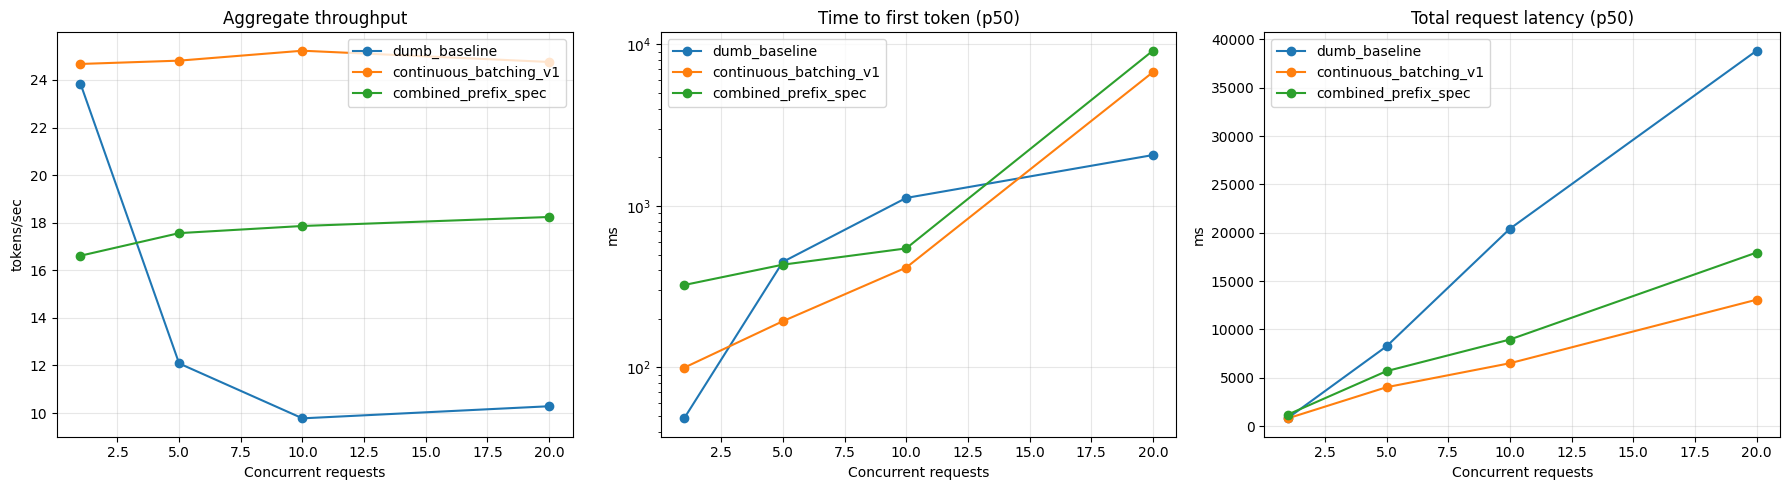

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results_log)
phases = ["dumb_baseline", "continuous_batching_v1", "combined_prefix_spec"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for phase in phases:
    sub = df[df["phase"] == phase]
    axes[0].plot(sub["concurrency"], sub["aggregate_tps"], marker="o", label=phase)
    axes[1].plot(sub["concurrency"], sub["ttft_p50"], marker="o", label=phase)
    axes[2].plot(sub["concurrency"], sub["latency_p50"], marker="o", label=phase)

axes[0].set_title("Aggregate throughput")
axes[0].set_xlabel("Concurrent requests")
axes[0].set_ylabel("tokens/sec")

axes[1].set_title("Time to first token (p50)")
axes[1].set_xlabel("Concurrent requests")
axes[1].set_ylabel("ms")
axes[1].set_yscale("log")

axes[2].set_title("Total request latency (p50)")
axes[2].set_xlabel("Concurrent requests")
axes[2].set_ylabel("ms")

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig("phase_comparison.png", dpi=150)
plt.show()

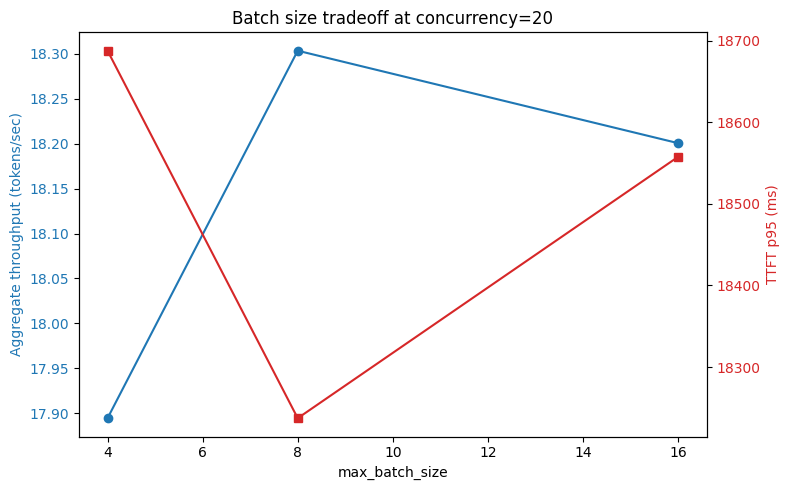

In [34]:
batch_df = df[df["phase"].str.startswith("batch_size_")].copy()
batch_df["batch_size"] = batch_df["phase"].str.replace("batch_size_", "").astype(int)
batch_df = batch_df.sort_values("batch_size")

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(batch_df["batch_size"], batch_df["aggregate_tps"], marker="o", color="tab:blue", label="aggregate throughput")
ax1.set_xlabel("max_batch_size")
ax1.set_ylabel("Aggregate throughput (tokens/sec)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(batch_df["batch_size"], batch_df["ttft_p95"], marker="s", color="tab:red", label="TTFT p95")
ax2.set_ylabel("TTFT p95 (ms)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Batch size tradeoff at concurrency=20")
fig.tight_layout()
plt.savefig("batch_size_sweep.png", dpi=150)
plt.show()

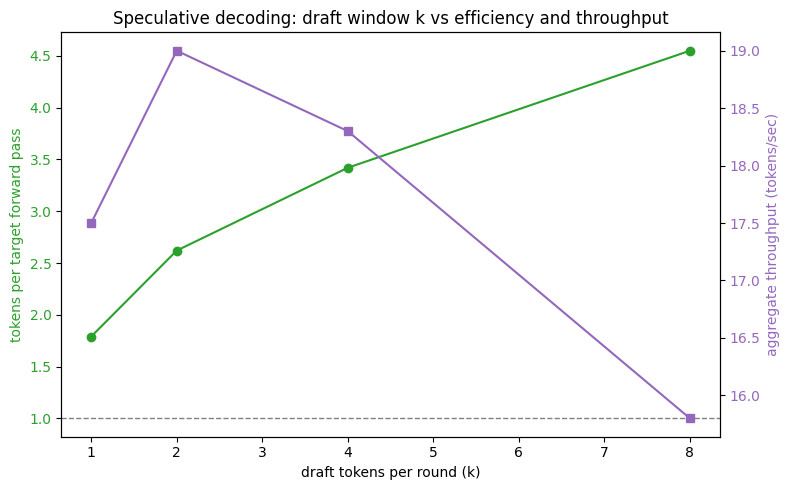

In [35]:
draft_k_stats = pd.DataFrame([
    {"k": 1, "tokens_per_target_call": 1.79, "aggregate_tps": 17.5},
    {"k": 2, "tokens_per_target_call": 2.62, "aggregate_tps": 19.0},
    {"k": 4, "tokens_per_target_call": 3.42, "aggregate_tps": 18.3},
    {"k": 8, "tokens_per_target_call": 4.55, "aggregate_tps": 15.8},
])

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(draft_k_stats["k"], draft_k_stats["tokens_per_target_call"], marker="o", color="tab:green", label="tokens per target forward pass")
ax1.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax1.set_xlabel("draft tokens per round (k)")
ax1.set_ylabel("tokens per target forward pass", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")

ax2 = ax1.twinx()
ax2.plot(draft_k_stats["k"], draft_k_stats["aggregate_tps"], marker="s", color="tab:purple", label="aggregate throughput")
ax2.set_ylabel("aggregate throughput (tokens/sec)", color="tab:purple")
ax2.tick_params(axis="y", labelcolor="tab:purple")

plt.title("Speculative decoding: draft window k vs efficiency and throughput")
fig.tight_layout()
plt.savefig("draft_k_sweep.png", dpi=150)
plt.show()